In [ ]:
import os
import urllib.request
import zipfile
from functools import partial

import pandas as pd
import xarray as xr
import pynncml

from pynncml.datasets.dataset import LinkDataset
from pynncml.datasets.gauge_data import PointSensor
from pynncml.datasets import PointSet
import numpy as np
import netCDF4 as nc

from pynncml.datasets.xarray_processing import xarray2link, LinkSelection

from scipy.interpolate import interp1d

import sys
from pathlib import Path

from load_link_set import *

C:\Users\gabir\Documents\OpenMesh_pynncml\PyNNcml\pynncml\model_zoo\model_common.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
import os
from pathlib import Path

# find the OpenMesh-1 root automatically
root = Path.cwd()

while root.name != "OpenMesh_pynncml":
    root = root.parent

os.chdir(root)
print("Working directory set to:", root)


Working directory set to: c:\Users\gabir\Documents\OpenMesh_pynncml


In [3]:
import sys
from pathlib import Path

# Add the notebooks directory to Python path
# Since Cell 1 changes cwd to project root, we need the relative path from there
notebooks_dir = Path.cwd() / 'src' / 'analysis' / 'pynncml_experiments' / 'notebooks'
if str(notebooks_dir) not in sys.path:
    sys.path.insert(0, str(notebooks_dir))

Import files

In [4]:
# ============================================
# PATH CONFIGURATION
# ============================================
from pathlib import Path

# Choose user
USER = "gabir"  # Options: "user" or "dror"

# Base path (relative to project root - Cell 1 sets working directory to project root)
BASE_PATH = Path("dataset")

# All paths built from base path
linkspath = str(BASE_PATH / "links" / "ds_openmesh.nc")
metapath = str(BASE_PATH / "links" / "links_metadata.csv")
# Note: pws_opensense_sample_jan.nc is in dataset root, not in weather stations folder
gaugespath = str(BASE_PATH / "weather stations" / "pws_opensense_sample_jan.nc")
gaugemetapath = str(BASE_PATH / "weather stations" / "pws_metadata.csv")

# Load data
with xr.open_dataset(linkspath) as ds:
    pass
links_meta = pd.read_csv(metapath)




1. Gauge data to Point Sensors

In [5]:
# CREATE POINT SENSORS
ps = guage_to_linkset(gaugemetapath, gaugespath)


CONVERTING NETCDF GROUPS TO XARRAY DICT

  ✓ KNYNEWYO1472: 4402 records
  ✓ KNYNEWYO1659: 4606 records
  ✓ KNYNEWYO1288: 3743 records
  ✓ KNYNEWYO1896: 4606 records
  ✓ KNYNEWYO1921: 4605 records
  ✓ KNYNEWYO1931: 4606 records
  ✓ KNYNEWYO1313: 4604 records
  ✓ KNYNEWYO1918: 4604 records
  ✓ KNYNEWYO1298: 4606 records
  ✓ KNYNEWYO1388: 4599 records
  ✓ KNYNEWYO1606: 4606 records
  ✓ KNYNEWYO1943: 290 records
  ✓ KNYNEWYO1348: 4606 records
  ✓ KNYNEWYO1942: 373 records
  ✓ KNYNEWYO1238: 4544 records
  ✓ KNYNEWYO1401: 4587 records
  ✓ KNYNEWYO1824: 4605 records
  ✓ KNYNEWYO343: 4606 records
  ✓ KNYNEWYO1626: 4604 records
  ✓ KNYNEWYO1747: 1171 records
  ✓ KNYNEWYO589: 4605 records
  ✓ KNYNEWYO1591: 4606 records
  ✓ KNYNEWYO638: 3958 records
  ✓ KNYNEWYO1796: 4606 records
  ✓ KNYNEWYO1805: 4534 records
  ✓ KNYNEWYO1622: 4606 records
  ✓ KNYNEWYO1024: 1506 records
  ✓ KNYNEWYO1533: 4580 records
  ✓ KNYNEWYO1651: 1534 records
  ✓ KNYNEWYO1120: 4606 records
  ✓ KNYNEWYO1900: 4605 records
  

2. Create LinkSet

In [6]:
# Create the LinkSet from 24/01 until 31/01
link_set = patched_xarray2link_with_gauges(ds, ps, max_distance=5000, change2min_max=True, time_slice=True, start='2024-01-14', end='2024-01-31')

print(f"✅ Created LinkSet with {len(link_set)} sublinks")

Processing sublinks:   0%|          | 0/3 [00:00<?, ?it/s]

c:\Users\gabir\Documents\OpenMesh_pynncml\src\analysis\pynncml_experiments\notebooks\load_link_set.py:270: RuntimeWarning: Mean of empty slice
  averaged_data = np.nanmean(stacked_arrays, axis=0)
c:\Users\gabir\Documents\OpenMesh_pynncml\src\analysis\pynncml_experiments\notebooks\load_link_set.py:270: RuntimeWarning: Mean of empty slice
  averaged_data = np.nanmean(stacked_arrays, axis=0)
c:\Users\gabir\Documents\OpenMesh_pynncml\src\analysis\pynncml_experiments\notebooks\load_link_set.py:270: RuntimeWarning: Mean of empty slice
  averaged_data = np.nanmean(stacked_arrays, axis=0)
c:\Users\gabir\Documents\OpenMesh_pynncml\src\analysis\pynncml_experiments\notebooks\load_link_set.py:270: RuntimeWarning: Mean of empty slice
  averaged_data = np.nanmean(stacked_arrays, axis=0)
c:\Users\gabir\Documents\OpenMesh_pynncml\src\analysis\pynncml_experiments\notebooks\load_link_set.py:270: RuntimeWarning: Mean of empty slice
  averaged_data = np.nanmean(stacked_arrays, axis=0)
c:\Users\gabir\Docum


Processing Summary:
  ✅ Valid links created: 100
  ⚠️  Skipped (missing coordinates): 0
  ⚠️  Skipped (no RSL data): 125
  📊 Total processed: 225

✅ Created LinkSet with 100 sublinks


Get high frequency links:

In [8]:
highfreqID = []
for i in range(0,len(link_set)):
    if link_set.get_link(i).meta_data.frequency >= 68:
        highfreqID.append(i)

In [ ]:
HF_set = keep_links(link_set, highfreqID, True)

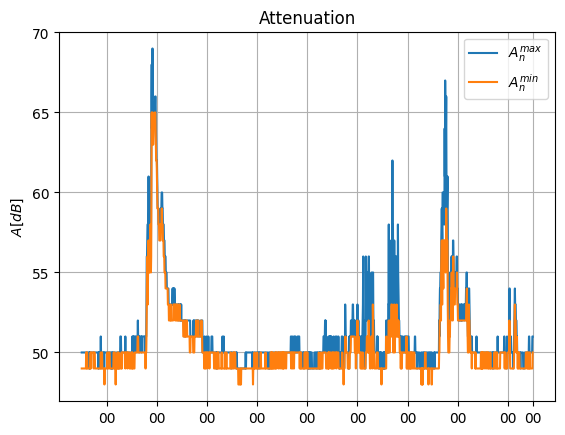

In [ ]:
link0 = HF_set.get_link(0)
link0.plot()

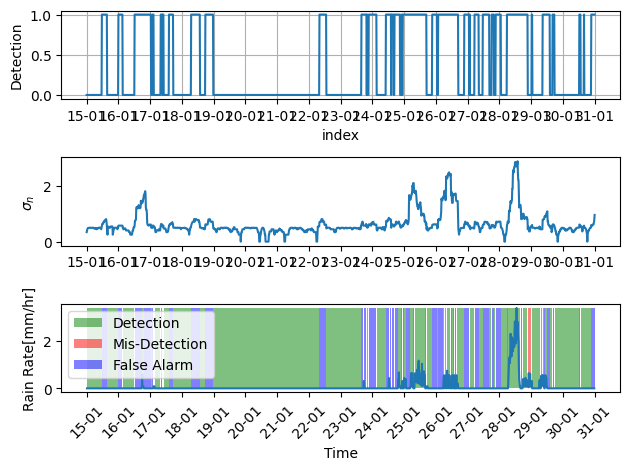

Accuracy:  70.5%
Precision: 28.1%
Recall:    85.1%


{'TPR': np.float64(0.8505154639175257), 'FPR': np.float64(0.31469052945563014)}

In [12]:
threshold = 0.55
stats = classification_plot(link0, threshold, 15, is_minmax=True)
stats

In [16]:
thresholds = np.arange(0, 0.85, 0.05)

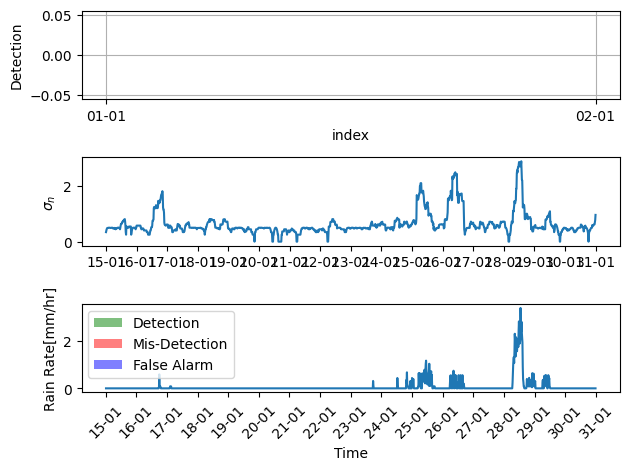

c:\Users\gabir\Documents\OpenMesh_pynncml\src\analysis\pynncml_experiments\notebooks\load_link_set.py:450: RuntimeWarning: invalid value encountered in scalar divide
  stats = {"TPR":tp/(tp+fn), "FPR":fp/(fp+tn)}


Accuracy:  0.0%
Precision: 0.0%
Recall:    0.0%


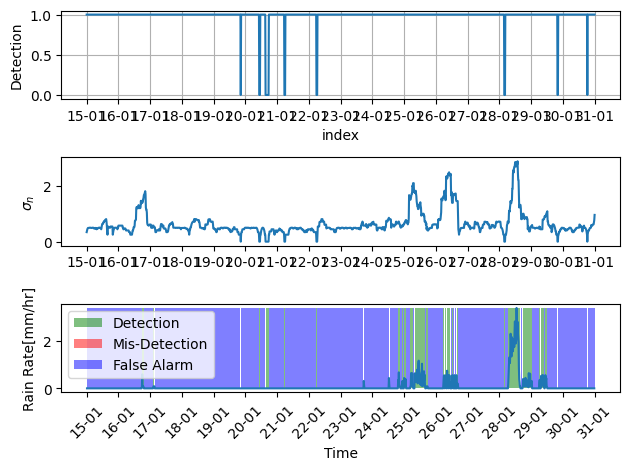

Accuracy:  14.3%
Precision: 12.9%
Recall:    100.0%


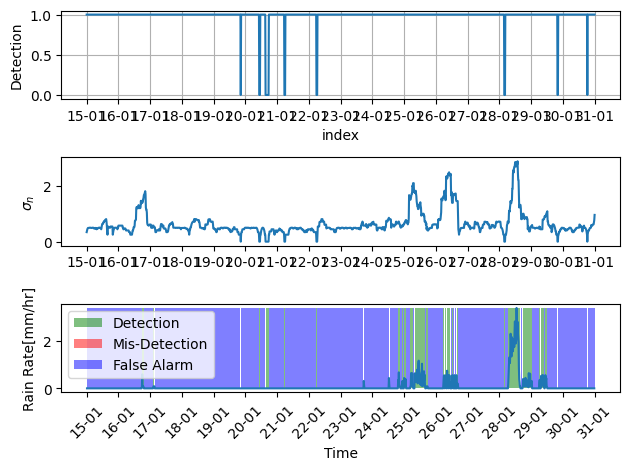

Accuracy:  14.3%
Precision: 12.9%
Recall:    100.0%


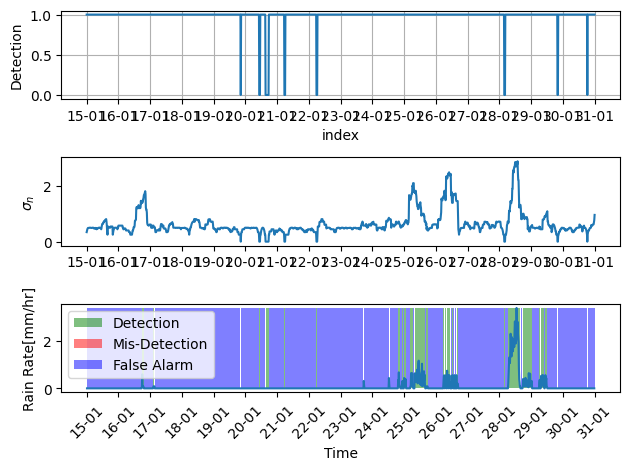

Accuracy:  14.3%
Precision: 12.9%
Recall:    100.0%


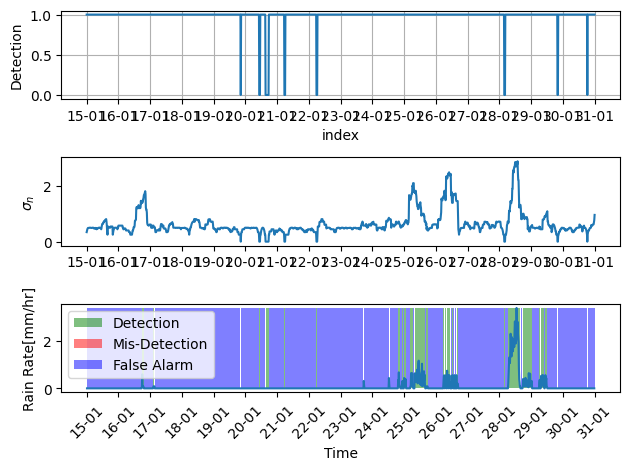

Accuracy:  14.3%
Precision: 12.9%
Recall:    100.0%


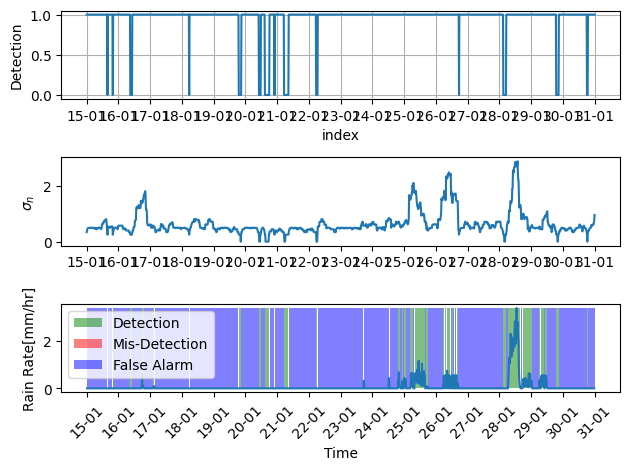

Accuracy:  17.7%
Precision: 13.3%
Recall:    100.0%


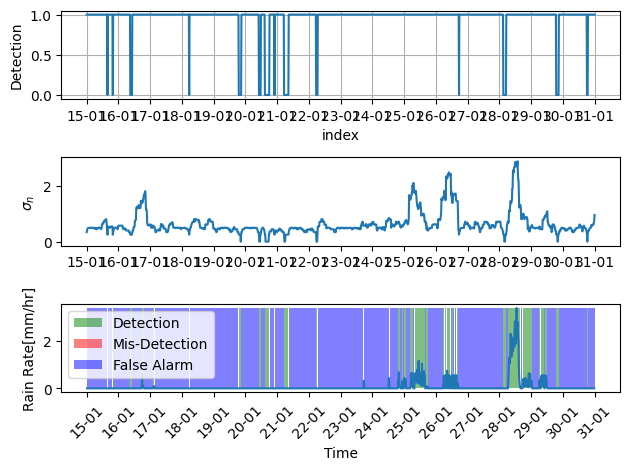

Accuracy:  17.7%
Precision: 13.3%
Recall:    100.0%


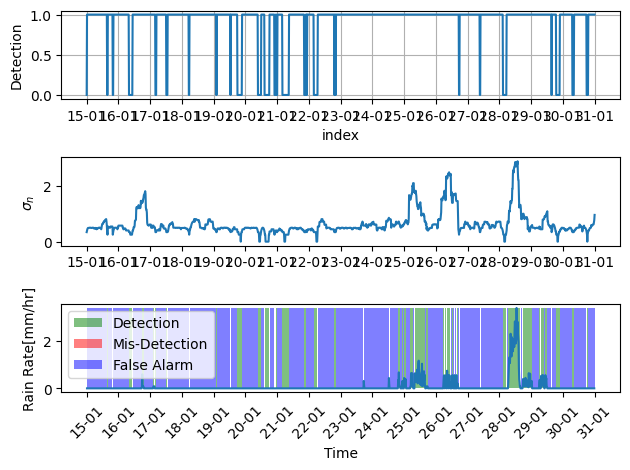

Accuracy:  22.5%
Precision: 14.0%
Recall:    100.0%


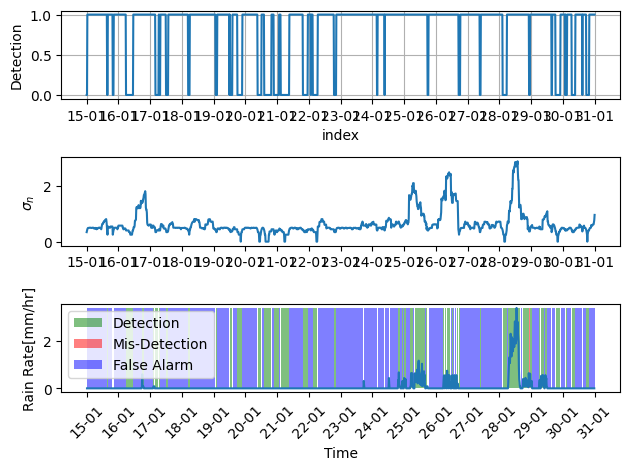

Accuracy:  29.5%
Precision: 15.0%
Recall:    97.9%


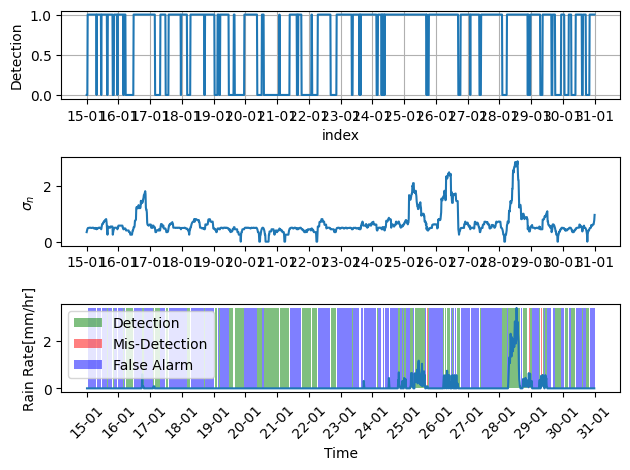

Accuracy:  37.3%
Precision: 15.9%
Recall:    92.3%


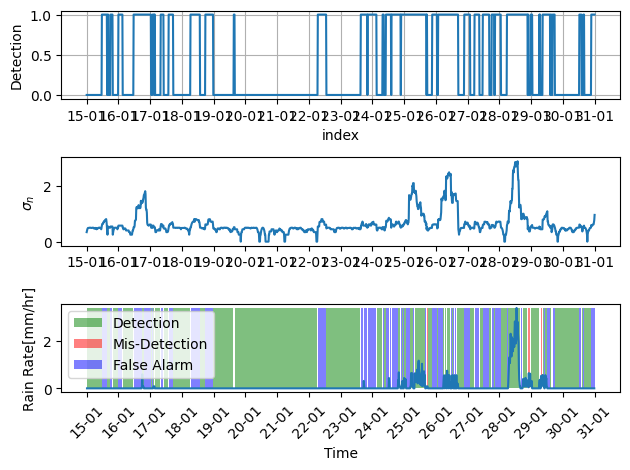

Accuracy:  67.5%
Precision: 26.8%
Recall:    90.2%


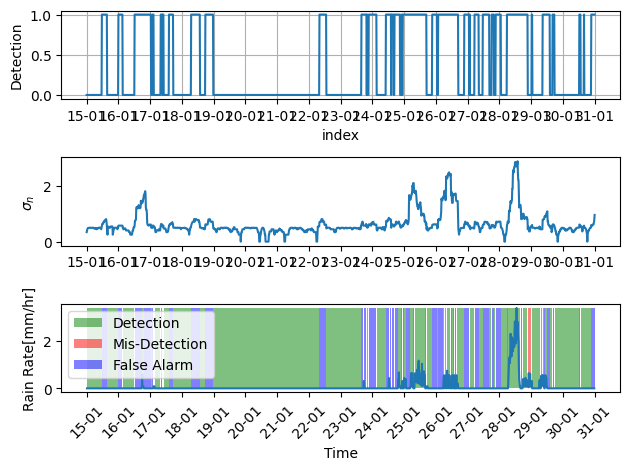

Accuracy:  70.5%
Precision: 28.1%
Recall:    85.1%


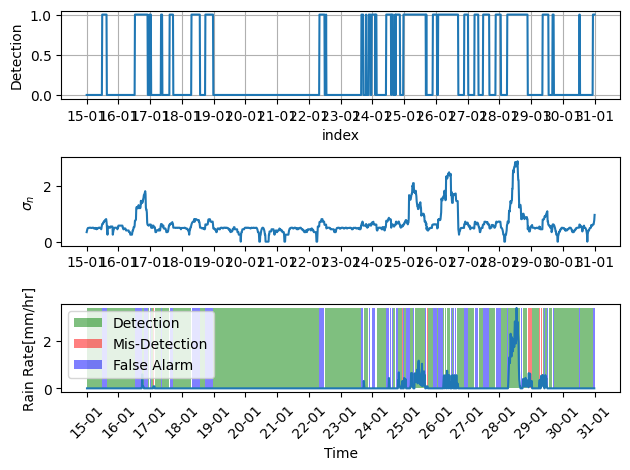

Accuracy:  75.9%
Precision: 32.3%
Recall:    82.0%


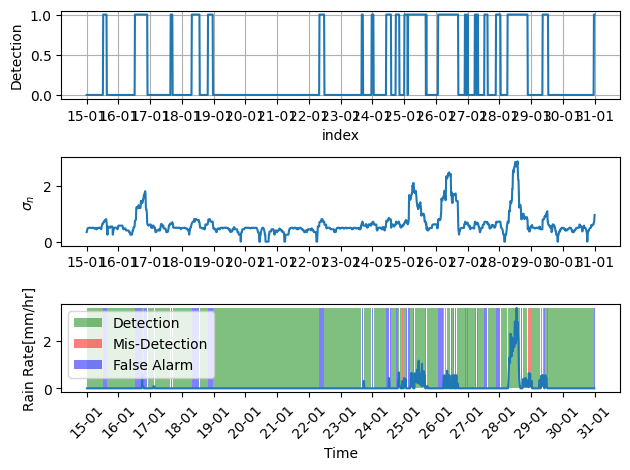

Accuracy:  82.3%
Precision: 40.2%
Recall:    80.4%


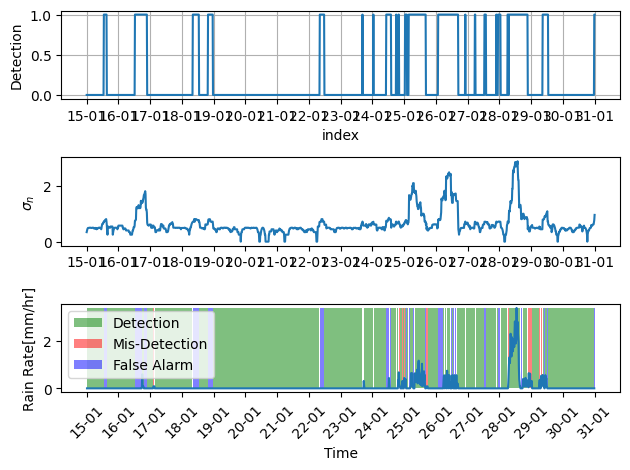

Accuracy:  85.4%
Precision: 45.6%
Recall:    76.8%


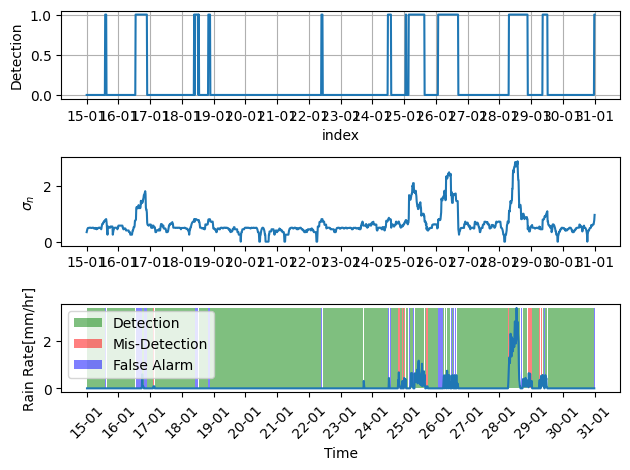

Accuracy:  89.3%
Precision: 56.1%
Recall:    73.7%


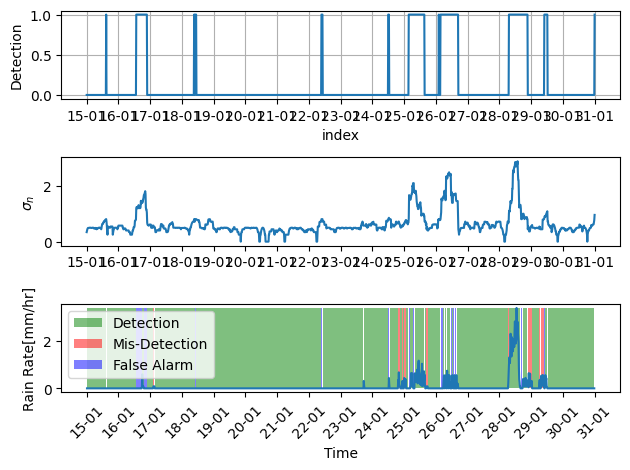

Accuracy:  90.9%
Precision: 63.0%
Recall:    70.1%


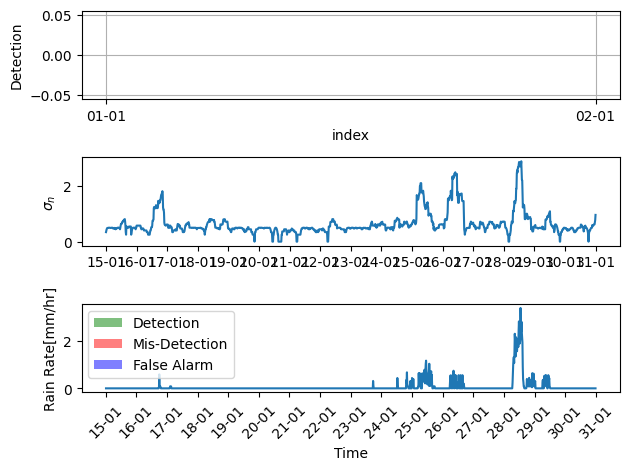

Accuracy:  0.0%
Precision: 0.0%
Recall:    0.0%


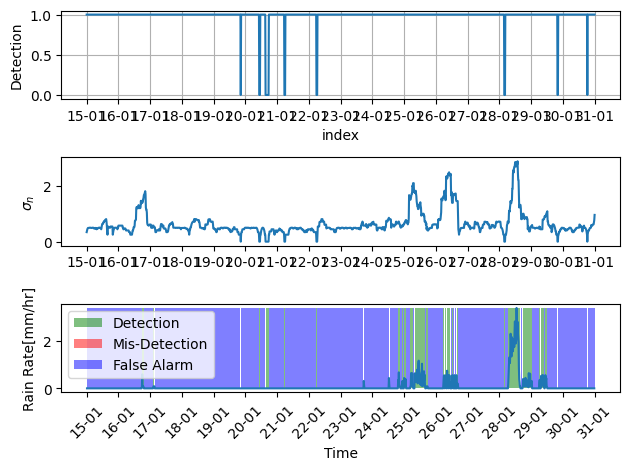

Accuracy:  14.3%
Precision: 12.9%
Recall:    100.0%


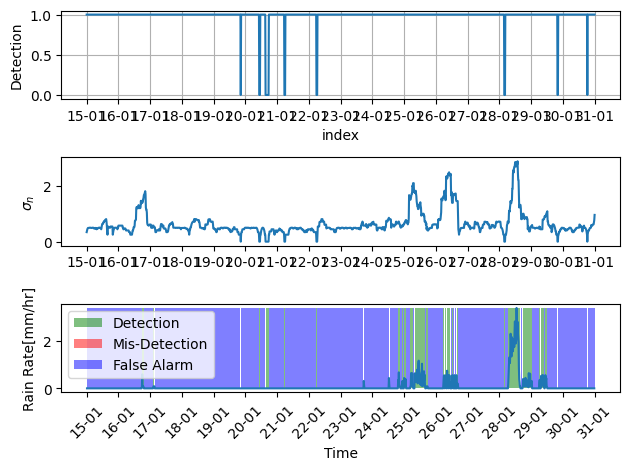

Accuracy:  14.3%
Precision: 12.9%
Recall:    100.0%


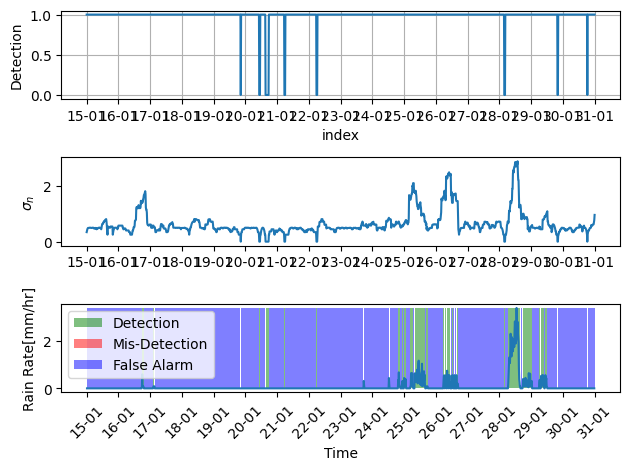

Accuracy:  14.3%
Precision: 12.9%
Recall:    100.0%


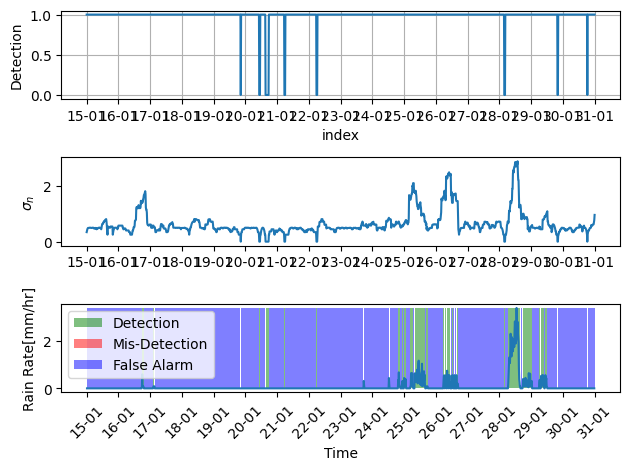

Accuracy:  14.3%
Precision: 12.9%
Recall:    100.0%


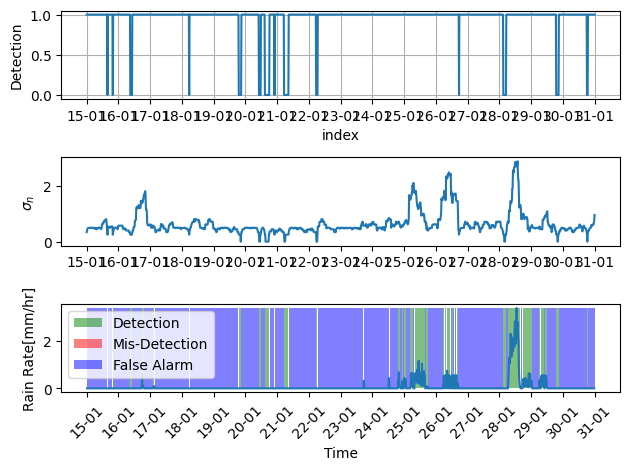

Accuracy:  17.7%
Precision: 13.3%
Recall:    100.0%


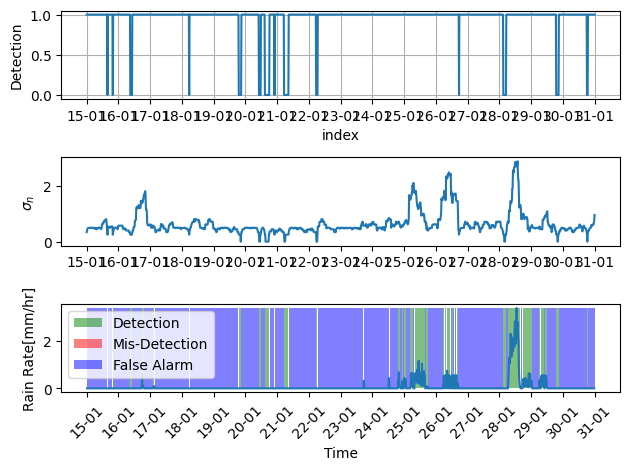

Accuracy:  17.7%
Precision: 13.3%
Recall:    100.0%


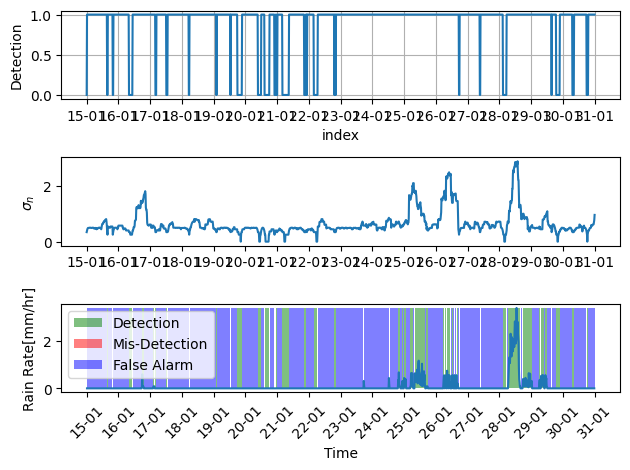

Accuracy:  22.5%
Precision: 14.0%
Recall:    100.0%


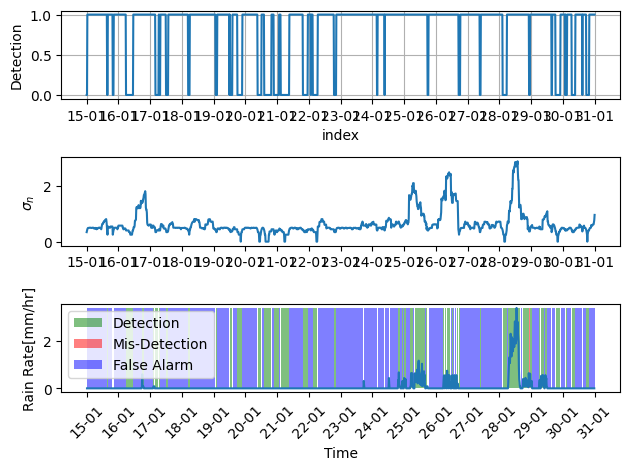

Accuracy:  29.5%
Precision: 15.0%
Recall:    97.9%


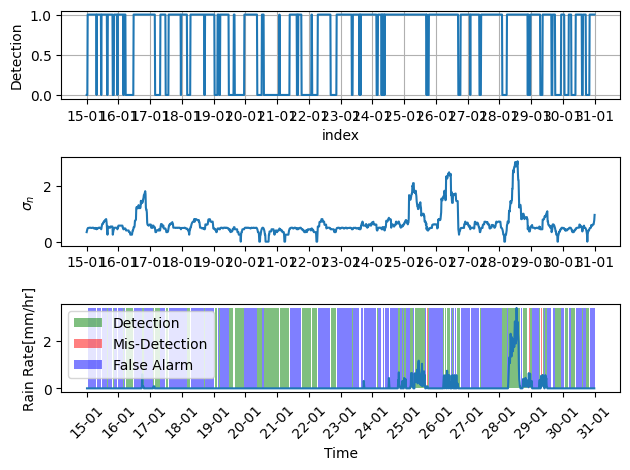

Accuracy:  37.3%
Precision: 15.9%
Recall:    92.3%


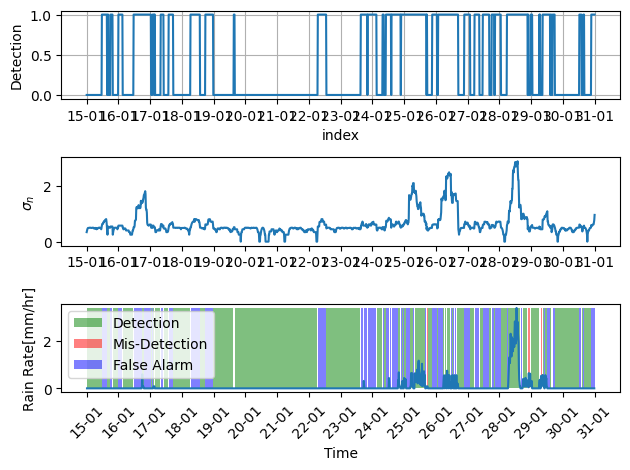

Accuracy:  67.5%
Precision: 26.8%
Recall:    90.2%


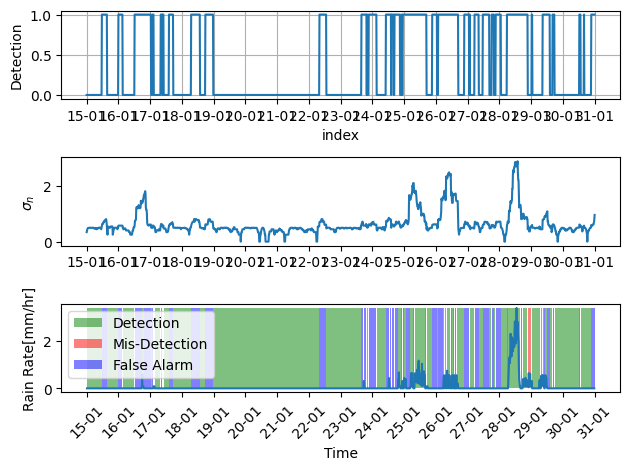

Accuracy:  70.5%
Precision: 28.1%
Recall:    85.1%


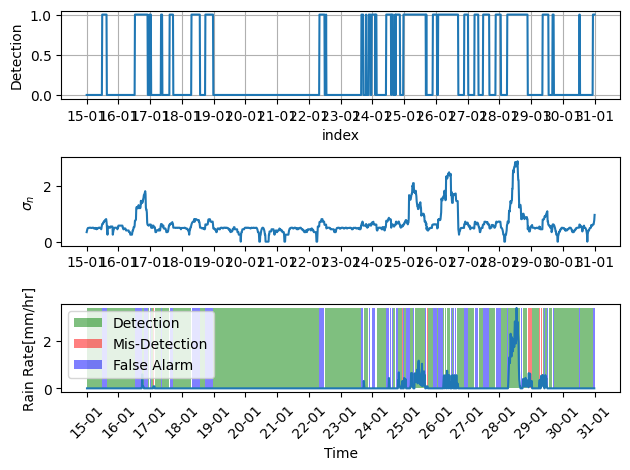

Accuracy:  75.9%
Precision: 32.3%
Recall:    82.0%


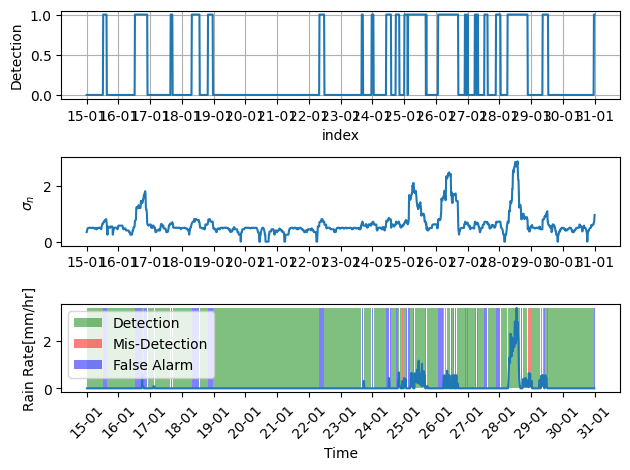

Accuracy:  82.3%
Precision: 40.2%
Recall:    80.4%


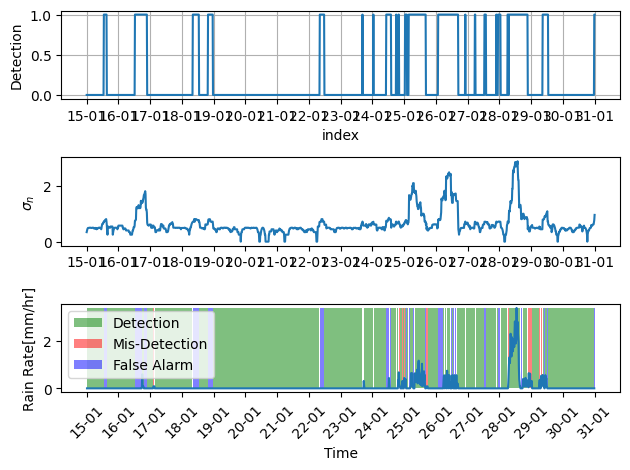

Accuracy:  85.4%
Precision: 45.6%
Recall:    76.8%


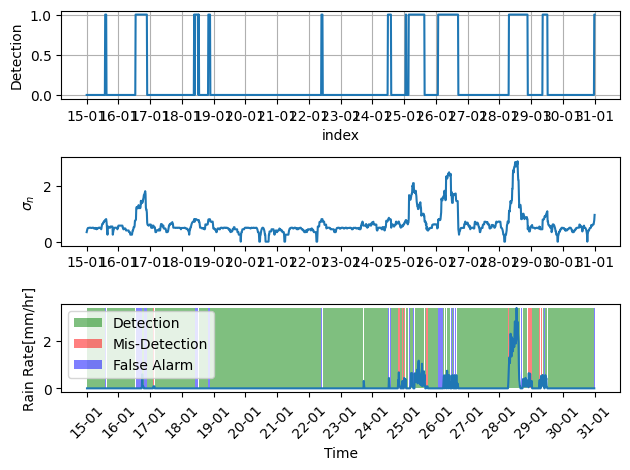

Accuracy:  89.3%
Precision: 56.1%
Recall:    73.7%


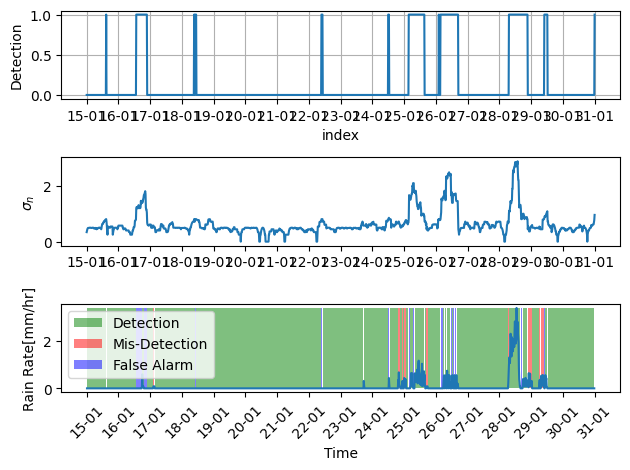

Accuracy:  90.9%
Precision: 63.0%
Recall:    70.1%


In [17]:
TPRs = [classification_plot(link0, t, 15, is_minmax=True)['TPR'] for t in thresholds]
FPRs = [classification_plot(link0, t, 15, is_minmax=True)['FPR'] for t in thresholds]

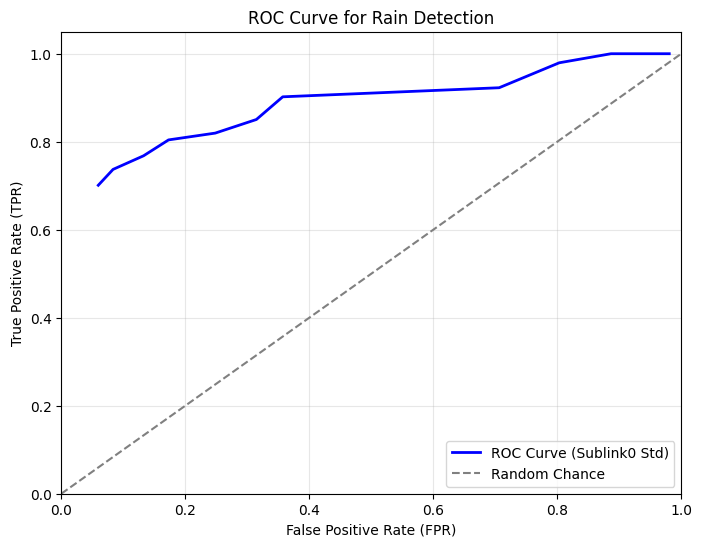

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

# Plot the ROC Curve
plt.plot(FPRs, TPRs, color='blue', lw=2, label='ROC Curve (Sublink0 Std)')

# Plot the "Random Guess" line
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Chance')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve for Rain Detection')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [20]:
# Convert your lists to arrays
fpr_arr = np.array(FPRs)
tpr_arr = np.array(TPRs)
thresh_arr = np.array(thresholds)

# Calculate distance to the "Perfect" point (0, 1)
# Distance = sqrt( FPR^2 + (1-TPR)^2 )
distances = np.sqrt(fpr_arr**2 + (1 - tpr_arr)**2)

# Find the index of the minimum distance
best_idx = np.nanargmin(distances)

print(f"Best Threshold: {thresh_arr[best_idx]}")
print(f"Resulting TPR: {tpr_arr[best_idx]:.2f}")
print(f"Resulting FPR: {fpr_arr[best_idx]:.2f}")

Best Threshold: 0.65
Resulting TPR: 0.80
Resulting FPR: 0.17


Build a function to find optimal threshold value

In [ ]:
def roc_threshold(link, window, is_minmax, step):
    # Array of thresholds
    thresholds = np.arange(0, 0.85, step)

    # Get TPR and FPR for every threshold
    TPRs = [classification_plot(link0, t, 15, is_minmax=True)['TPR'] for t in thresholds]
    FPRs = [classification_plot(link0, t, 15, is_minmax=True)['FPR'] for t in thresholds]

    plt.figure(figsize=(8, 6))

    # Plot the ROC Curve
    plt.plot(FPRs, TPRs, color='blue', lw=2, label='ROC Curve (Sublink0 Std)')

    # Plot the "Random Guess" line
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Chance')

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.title('ROC Curve for Rain Detection')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()

    fpr_arr = np.array(FPRs)
    tpr_arr = np.array(TPRs)
    thresh_arr = np.array(thresholds)

    # Calculate distance to the "Perfect" point (0, 1)
    # Distance = sqrt( FPR^2 + (1-TPR)^2 )
    distances = np.sqrt(fpr_arr**2 + (1 - tpr_arr)**2)

    # Find the index of the minimum distance
    best_idx = np.nanargmin(distances)

    bestT = {"Best Threshold": thresh_arr[best_idx], "Resulting TPR": tpr_arr[best_idx], "Resulting FPR": fpr_arr[best_idx]}

    return bestT
    

In [ ]:
roc_threshold(HF_set.get_link(1), 15, True, 0.01)